In [11]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys, os
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)
from src.modeling_lgbm import clean_feature_names

In [4]:
# -------------------------------------------------------
# 1. Load data
# -------------------------------------------------------
ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(DATA_TRAIN)
X = X.drop(columns=[c for c in ["Unnamed: 0", "Unnamed_0", "respondent_id"] if c in X.columns])
y = pd.read_csv(DATA_LABELS)[["h1n1_vaccine", "seasonal_vaccine"]].astype(int)
X = clean_feature_names(X)

In [9]:
# -------------------------------------------------------
# 2. Train full-data LightGBM models for SHAP visualization
# -------------------------------------------------------
params_base = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 6,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 3,
    "lambda_l1": 0.5,
    "lambda_l2": 0.5,
    "verbose": -1,
    "force_col_wise": True,
}

# Train two separate models (H1N1 and Seasonal)
models, shap_results = {}, {}

for target in ["h1n1_vaccine", "seasonal_vaccine"]:
    print(f"Training LightGBM on full data for {target}...")
    dtrain = lgb.Dataset(X, label=y[target])
    model = lgb.train(params_base, dtrain, num_boost_round=500)
    models[target] = model

    print(f"Computing SHAP values for {target}...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)
    shap_results[target] = shap_values

Training LightGBM on full data for h1n1_vaccine...
Computing SHAP values for h1n1_vaccine...
Training LightGBM on full data for seasonal_vaccine...
Computing SHAP values for seasonal_vaccine...


In [12]:
# -------------------------------------------------------
# 3. Compute mean absolute SHAP values per feature
# -------------------------------------------------------
def summarize_shap_values(shap_values, X):
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    df = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    return df

shap_imp_h1n1 = summarize_shap_values(shap_results["h1n1_vaccine"], X)
shap_imp_seas = summarize_shap_values(shap_results["seasonal_vaccine"], X)

In [40]:
# -------------------------------------------------------
# 4. Display top 15 features in notebook
# -------------------------------------------------------
print("\n=== Top 15 Features by Mean |SHAP| Importance (H1N1 Vaccine) ===")
print(shap_imp_h1n1.head(15))



=== Top 15 Features by Mean |SHAP| Importance (H1N1 Vaccine) ===
                                feature  mean_abs_shap
0                      doctor_recc_h1n1       0.647193
1                  health_insurance_1_0       0.373841
2                     opinion_h1n1_risk       0.353224
3           opinion_h1n1_vacc_effective       0.346621
4              health_insurance_Missing       0.316196
5                             age_group       0.122850
6           opinion_h1n1_sick_from_vacc       0.116580
7                             PVAS_seas       0.104542
8                     opinion_seas_risk       0.101083
9                              sex_Male       0.100069
10                        health_worker       0.098414
11                            PVAS_h1n1       0.094356
12  employment_industry_te_h1n1_vaccine       0.092124
13                            education       0.072638
14                                  HRI       0.070261


In [41]:

print("\n=== Top 15 Features by Mean |SHAP| Importance (Seasonal Vaccine) ===")
print(shap_imp_seas.head(15))


=== Top 15 Features by Mean |SHAP| Importance (Seasonal Vaccine) ===
                                    feature  mean_abs_shap
0                                 PVAS_seas       0.499204
1                      doctor_recc_seasonal       0.476542
2                                 age_group       0.427142
3               opinion_seas_vacc_effective       0.365014
4                         opinion_seas_risk       0.326789
5                      health_insurance_1_0       0.222674
6                          PVASxDoctor_seas       0.127472
7   employment_industry_te_seasonal_vaccine       0.082225
8               opinion_seas_sick_from_vacc       0.076534
9                                       HRI       0.075384
10                                education       0.074629
11                           h1n1_knowledge       0.073778
12                            health_worker       0.072510
13      employment_industry_te_h1n1_vaccine       0.069395
14                    behavioral_touch_face  

In [15]:
# -------------------------------------------------------
# 5. Save numeric importance tables
# -------------------------------------------------------
shap_imp_h1n1.to_csv(ARTIFACTS / "shap_importance_h1n1.csv", index=False)
shap_imp_seas.to_csv(ARTIFACTS / "shap_importance_seasonal.csv", index=False)

print(f"Saved SHAP importance tables to {ARTIFACTS}")

Saved SHAP importance tables to ..\artifacts_lgbm


Generating SHAP summary plots for h1n1_vaccine...


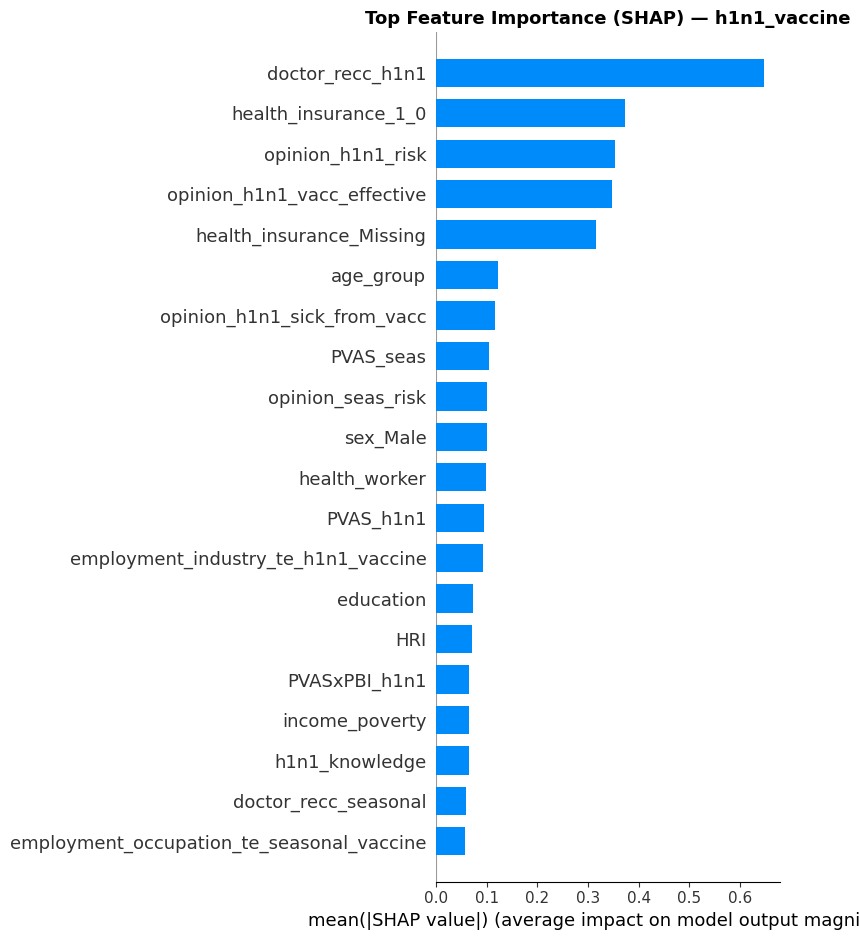

✅ Saved bar summary: ..\artifacts_lgbm\shap_summary_bar_h1n1_vaccine.png


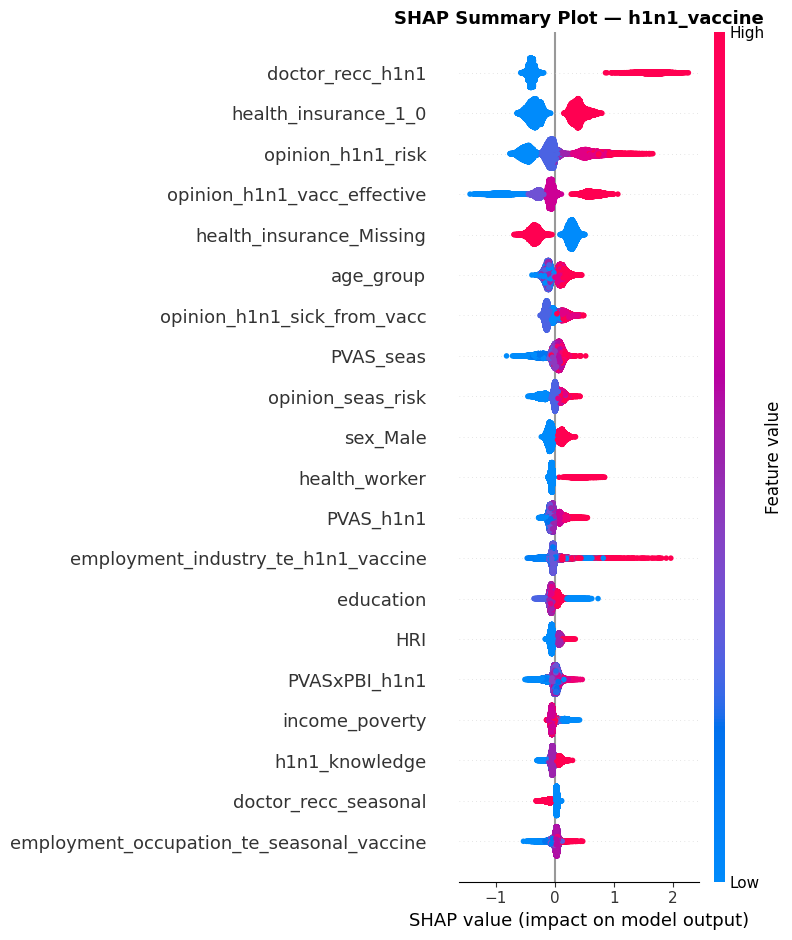

✅ Saved beeswarm summary: ..\artifacts_lgbm\shap_summary_beeswarm_h1n1_vaccine.png

Generating SHAP summary plots for seasonal_vaccine...


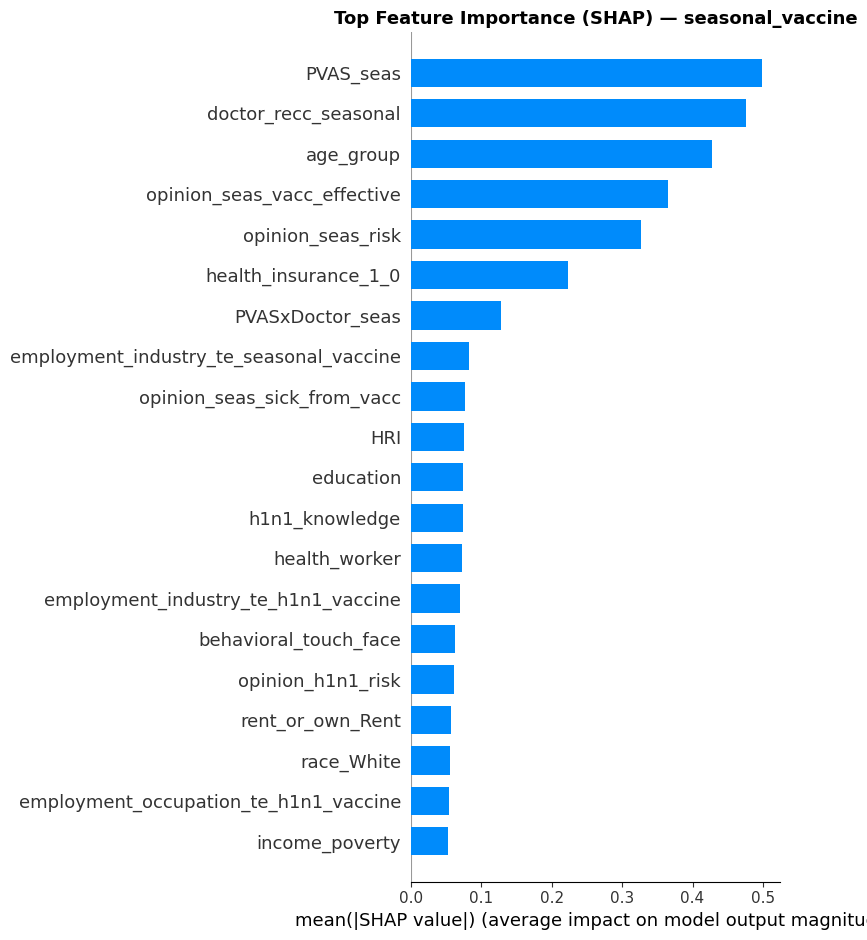

✅ Saved bar summary: ..\artifacts_lgbm\shap_summary_bar_seasonal_vaccine.png


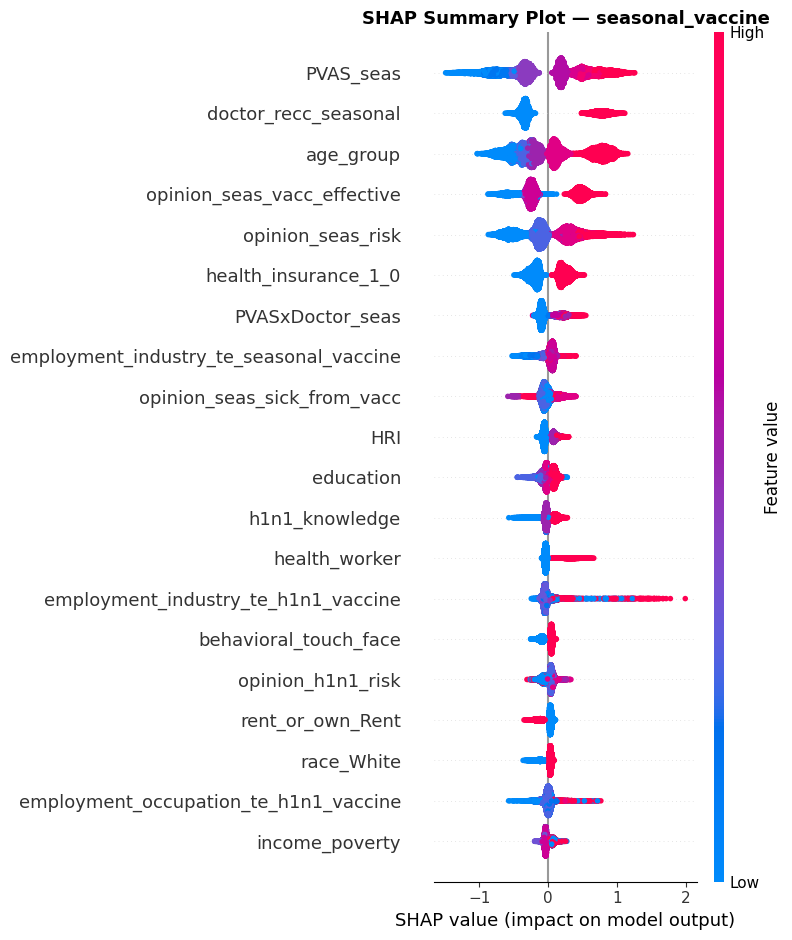

✅ Saved beeswarm summary: ..\artifacts_lgbm\shap_summary_beeswarm_seasonal_vaccine.png



In [16]:
# Ensure artifacts folder exists
ARTIFACTS = Path(ROOT) / "artifacts_lgbm"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Function to plot SHAP summary (bar + beeswarm)
# -------------------------------------------------------
def plot_shap_summary(shap_values, X, target, artifacts_dir):
    """
    Generates and saves SHAP bar + beeswarm plots.
    Displays them inline and exports as .png files.
    """
    print(f"Generating SHAP summary plots for {target}...")

    # --- Bar plot (mean |SHAP| importance) ---
    plt.figure()
    shap.summary_plot(shap_values.values, X, show=False, plot_type="bar")
    plt.title(f"Top Feature Importance (SHAP) — {target}", fontsize=13, weight="bold")
    plt.tight_layout()
    bar_path = artifacts_dir / f"shap_summary_bar_{target}.png"
    plt.savefig(bar_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved bar summary: {bar_path}")

    # --- Beeswarm plot (full distribution) ---
    plt.figure()
    shap.summary_plot(shap_values.values, X, show=False)
    plt.title(f"SHAP Summary Plot — {target}", fontsize=13, weight="bold")
    plt.tight_layout()
    beeswarm_path = artifacts_dir / f"shap_summary_beeswarm_{target}.png"
    plt.savefig(beeswarm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved beeswarm summary: {beeswarm_path}\n")

# -------------------------------------------------------
# Apply to both vaccine models
# -------------------------------------------------------
plot_shap_summary(shap_results["h1n1_vaccine"], X, "h1n1_vaccine", ARTIFACTS)
plot_shap_summary(shap_results["seasonal_vaccine"], X, "seasonal_vaccine", ARTIFACTS)


### SHAP Feature Importance Analysis

We used SHAP (SHapley Additive exPlanations) to quantify how much each feature contributed to model predictions for **H1N1 Vaccine** and **Seasonal Vaccine** uptake.  
The tables below represent the *mean absolute SHAP value* per feature - higher values indicate stronger overall influence on the model’s output.

---

#### H1N1 Vaccine - Key Predictors

| Rank | Feature | Mean SHAP | Interpretation |
|:--|:--|:--:|:--|
| 1 | **doctor_recc_h1n1** | 0.65 | Strongest positive driver - individuals who received a doctor’s recommendation for the H1N1 shot were far more likely to vaccinate. |
| 2 | **health_insurance_1_0 / Missing** | 0.37 / 0.32 | Health insurance coverage (or lack thereof) heavily influenced uptake, reflecting access to healthcare. |
| 3 | **opinion_h1n1_risk** | 0.35 | Perceived personal risk of H1N1 infection increased vaccination likelihood. |
| 4 | **opinion_h1n1_vacc_effective** | 0.35 | Belief in vaccine effectiveness strongly shaped vaccination intent. |
| 5 | **age_group / education** | 0.12 / 0.07 | Older and more educated respondents tended to vaccinate more often. |
| 6 | **health_worker** | 0.10 | Medical staff were more likely to be vaccinated, consistent with occupational exposure. |
| 7 | **PVAS_seas / PVAS_h1n1** | 0.10 / 0.09 | Positive vaccine attitude scores (aggregated from opinions) showed strong alignment with uptake. |
| 8 | **HRI (Health Risk Index)** | 0.07 | Individuals with chronic conditions or higher vulnerability also showed higher predicted vaccination likelihood. |

**Summary:**  
H1N1 vaccination was primarily driven by *trusted medical recommendation, perceived disease risk, and belief in vaccine efficacy*, modulated by access to healthcare and demographic vulnerability.  
The influence of opinion-based and behavioral indicators confirms the behavioral nature of vaccine hesitancy for H1N1.

---

#### Seasonal Vaccine - Key Predictors

| Rank | Feature | Mean SHAP | Interpretation |
|:--|:--|:--:|:--|
| 1 | **PVAS_seas** | 0.50 | Aggregate vaccine-attitude score: the single most powerful predictor of seasonal vaccine uptake. |
| 2 | **doctor_recc_seasonal** | 0.48 | Physician recommendation remains a dominant behavioral trigger. |
| 3 | **age_group** | 0.43 | Older respondents are substantially more likely to get the seasonal flu shot. |
| 4 | **opinion_seas_vacc_effective / risk** | 0.36 / 0.33 | Confidence in vaccine effectiveness and perceived infection risk jointly drive uptake. |
| 5 | **health_insurance_1_0** | 0.22 | Having insurance improves access and correlates with higher vaccination rates. |
| 6 | **PVASxDoctor_seas** | 0.13 | Interaction effect: positive attitudes amplify the impact of doctor recommendations. |
| 7 | **employment_industry_te_seasonal_vaccine** | 0.08 | Industry-based target encoding suggests certain occupations are associated with higher uptake. |
| 8 | **HRI / education / health_worker** | 0.07–0.08 | Health risk, education, and healthcare employment further reinforce vaccination likelihood. |

**Summary:**  
Seasonal vaccine uptake is influenced by **routine healthcare engagement and positive vaccine attitudes**, with a stronger demographic component (age, insurance, and occupation).  
The model captures both *behavioral trust factors* (doctor advice, vaccine belief) and *structural access factors* (insurance, age).

---

#### Comparative Insights

| Theme | H1N1 Vaccine | Seasonal Vaccine |
|:--|:--|:--|
| **Primary driver** | Doctor recommendation | Vaccine attitude (PVAS_seas) |
| **Perceived risk & efficacy** | Strong influence | Strong but secondary |
| **Access to healthcare** | Key (insurance coverage critical) | Important, but less dominant |
| **Demographic impact** | Moderate (education, health worker) | Strong (age, insurance, chronic risk) |
| **Behavioral overlap** | Opinion and PVAS cross-effects visible | Opinion × Doctor interactions dominant |

**Interpretation:**  
Both models confirm that **trust and healthcare access** are universal vaccination drivers, but:
- H1N1 uptake hinges more on **individual perception and targeted recommendations**.  
- Seasonal uptake follows **habitual or demographic patterns** (age, insurance, established trust).

---

**Takeaway:**  
SHAP analysis highlights actionable levers for intervention:
- Strengthen doctor-patient communication* to increase **H1N1** uptake among hesitant groups.  
- Maintain routine outreach among older and insured populations for **seasonal** campaigns.  
- Tailor public messaging to reinforce vaccine efficacy and risk awareness where these beliefs are weak.

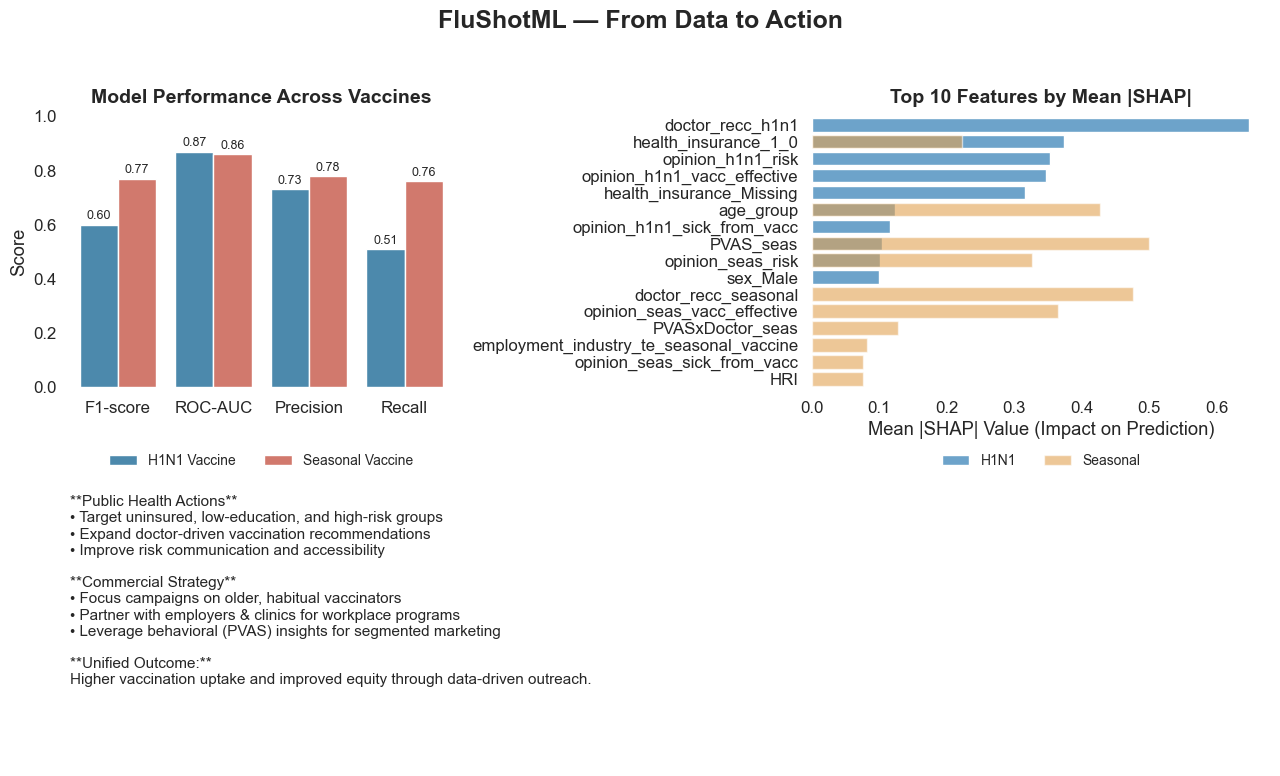

✅ Final summary figure saved to: ..\artifacts_lgbm\FluShotML_visual_summary_final.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

# -------------------------------
# Data Setup
# -------------------------------
metrics_data = {
    "Metric": ["F1-score", "ROC-AUC", "Precision", "Recall"],
    "H1N1 Vaccine": [0.60, 0.87, 0.73, 0.51],
    "Seasonal Vaccine": [0.77, 0.86, 0.78, 0.76],
}
df_metrics = pd.DataFrame(metrics_data)

df_shap_h1n1 = shap_imp_h1n1.head(10)
df_shap_seas = shap_imp_seas.head(10)

# -------------------------------
# Style setup
# -------------------------------
palette_perf = ["#3C8DBC", "#E26D5C"]   # blue/coral for vaccines
palette_shap = {"H1N1": "#5DA5DA", "Seasonal": "#FAA43A"}

sns.set_theme(style="white", font_scale=1.1)  # clean and minimal

# -------------------------------
# Figure Layout (3 panels)
# -------------------------------
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1.2])
fig.suptitle("FluShotML — From Data to Action", fontsize=18, fontweight="bold", y=0.97)

# (1) Top-left: Model performance
ax1 = fig.add_subplot(gs[0, 0])
df_melt = df_metrics.melt("Metric", var_name="Model", value_name="Score")
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette=palette_perf, ax=ax1)
ax1.set_ylim(0, 1)
ax1.set_title("Model Performance Across Vaccines", fontsize=14, weight="bold", pad=10)
ax1.set_ylabel("Score")
ax1.set_xlabel("")
ax1.legend(
    title="", 
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),  # positions legend below the axis
    frameon=False,
    ncol=2,                       # number of columns
    fontsize=10
)
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)
for p in ax1.patches:
    height = p.get_height()
    if height > 0.01:  # avoid clutter for bars near zero
        ax1.annotate(f"{height:.2f}",
                     (p.get_x() + p.get_width() / 2, height + 0.02),
                     ha="center", fontsize=9)


# (2) Top-right: SHAP Global Importance
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(y="feature", x="mean_abs_shap", data=df_shap_h1n1,
            color=palette_shap["H1N1"], label="H1N1", ax=ax2)
sns.barplot(y="feature", x="mean_abs_shap", data=df_shap_seas,
            color=palette_shap["Seasonal"], alpha=0.6, label="Seasonal", ax=ax2)
ax2.set_title("Top 10 Features by Mean |SHAP|", fontsize=14, weight="bold", pad=10)
ax2.set_xlabel("Mean |SHAP| Value (Impact on Prediction)")
ax2.set_ylabel("")
ax2.legend(
    title="", 
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),  # positions legend below the axis
    frameon=False,
    ncol=2,                       # number of columns
    fontsize=10
)
ax2.set_facecolor("white")
for spine in ax2.spines.values():
    spine.set_visible(False)

# (3) Bottom row: Strategic Actions Text Box
ax3 = fig.add_subplot(gs[1, :])
ax3.axis("off")
text = (
    "**Public Health Actions**\n"
    "• Target uninsured, low-education, and high-risk groups\n"
    "• Expand doctor-driven vaccination recommendations\n"
    "• Improve risk communication and accessibility\n\n"
    "**Commercial Strategy**\n"
    "• Focus campaigns on older, habitual vaccinators\n"
    "• Partner with employers & clinics for workplace programs\n"
    "• Leverage behavioral (PVAS) insights for segmented marketing\n\n"
    "**Unified Outcome:**\n"
    "Higher vaccination uptake and improved equity through data-driven outreach."
)
ax3.text(0, 1, text, ha="left", va="top", fontsize=11, wrap=True)

# Add rounded background box to text area
bbox = FancyBboxPatch((0, 0), 1, 1, transform=ax3.transAxes,
                      boxstyle="round,pad=0.02", facecolor="white",
                      edgecolor="#BBBBBB", lw=1.5)
ax3.add_patch(bbox)

# -------------------------------
# Save and Display
# -------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
output_path = Path(ARTIFACTS) / "FluShotML_visual_summary_final.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Final summary figure saved to: {output_path}")
